# 🌱 Crop Recommendation using Ensemble Learning

This notebook builds a **crop recommendation system** using an ensemble of machine-learning classifiers. It uses soil nutrients (N, P, K), temperature, humidity, pH and rainfall to recommend a suitable crop.

**Dataset:** `crop_recommendation_1000.csv` — 1,000 records and 20 crop classes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

pd.set_option('display.max_columns', None)

In [2]:
## 1. Load Dataset

In [3]:
df = pd.read_csv('crop_recommendation_1000.csv')
print('Dataset shape:', df.shape)
display(df.head())
display(df.info())


Dataset shape: (1000, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,94.89,94.22,50.34,29.57,79.54,6.50,114.06,banana
1,72.48,19.73,40.38,29.91,69.06,6.38,39.41,muskmelon
2,91.30,19.60,49.61,32.39,61.54,6.78,49.93,muskmelon
3,85.62,14.79,50.44,27.52,83.04,6.64,50.68,watermelon
4,17.31,57.98,21.98,24.05,70.36,7.16,54.13,lentil


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            1000 non-null   float64
 1   P            1000 non-null   float64
 2   K            1000 non-null   float64
 3   temperature  1000 non-null   float64
 4   humidity     1000 non-null   float64
 5   ph           1000 non-null   float64
 6   rainfall     1000 non-null   float64
 7   label        1000 non-null   object 
dtypes: float64(7), object(1)
memory usage: 62.6+ KB


None

In [4]:
## 2. Basic Data Analysis

In [5]:
print('Missing values:')
print(df.isnull().sum())
df

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


,N,P,K,temperature,humidity,ph,rainfall,label
0,94.89,94.22,50.34,29.57,79.54,6.50,114.06,banana
1,72.48,19.73,40.38,29.91,69.06,6.38,39.41,muskmelon
2,91.30,19.60,49.61,32.39,61.54,6.78,49.93,muskmelon
3,85.62,14.79,50.44,27.52,83.04,6.64,50.68,watermelon
4,17.31,57.98,21.98,24.05,70.36,7.16,54.13,lentil
...,...,...,...,...,...,...,...,...
995,34.69,49.28,81.03,22.18,65.79,6.98,71.65,chickpea
996,30.12,40.42,14.32,24.12,53.40,6.80,32.59,mothbeans
997,49.38,38.90,49.05,28.10,69.98,6.67,146.55,papaya
998,18.13,69.10,22.61,25.10,73.54,7.25,37.53,lentil


In [6]:
print('\nCrop distribution:')
print(df['label'].value_counts())

display(df.describe())


Crop distribution:
label
banana         50
muskmelon      50
mango          50
pomegranate    50
pigeonpeas     50
blackgram      50
kidneybeans    50
mungbean       50
apple          50
mothbeans      50
coconut        50
cotton         50
maize          50
orange         50
chickpea       50
papaya         50
grapes         50
lentil         50
watermelon     50
rice           50
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,46.697740,51.999170,51.782310,24.984660,67.397390,6.472740,96.823470
std,35.335753,32.324578,53.761936,3.384189,11.776761,0.487658,46.643482
min,4.680000,2.200000,0.020000,14.730000,33.110000,5.050000,24.010000
25%,19.955000,24.735000,22.305000,22.567500,59.217500,6.120000,61.647500
50%,27.805000,47.340000,36.605000,25.465000,66.940000,6.470000,90.380000
75%,78.500000,65.585000,49.527500,27.485000,75.397500,6.810000,116.205000
max,156.310000,178.150000,263.090000,33.560000,100.000000,7.980000,296.930000


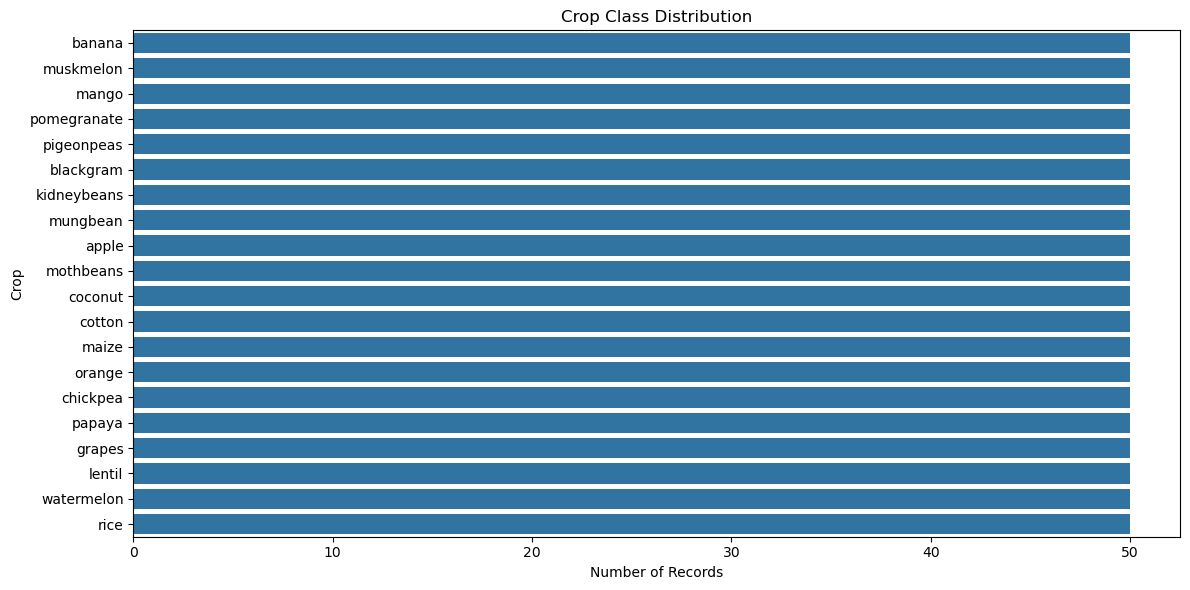

In [7]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index)
plt.title('Crop Class Distribution')
plt.xlabel('Number of Records')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()


In [8]:
## 3. Prepare Features and Target

In [9]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training records:', X_train.shape[0])
print('Testing records :', X_test.shape[0])

Training records: 800
Testing records : 200


## 4. Ensemble Learning Models

We compare several ensemble methods and then build a **Voting Ensemble**. The ensemble combines Random Forest, Extra Trees and Gradient Boosting so that multiple models contribute to the final recommendation.

In [11]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
et = ExtraTreesClassifier(n_estimators=200, random_state=42, class_weight='balanced')
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=3, random_state=42)

voting_model = VotingClassifier(
    estimators=[('rf', rf), ('et', et), ('gb', gb)],
    voting='soft'
)

models = {
    'Random Forest': rf,
    'Extra Trees': et,
    'Gradient Boosting': gb,
    'Voting Ensemble': voting_model
}


In [12]:
## 5. Train and Compare Models

In [13]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append({'Model': name, 'Accuracy': acc})
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
display(results_df)


,Model,Accuracy
0,Random Forest,0.945
1,Extra Trees,0.945
3,Voting Ensemble,0.940
2,Gradient Boosting,0.920


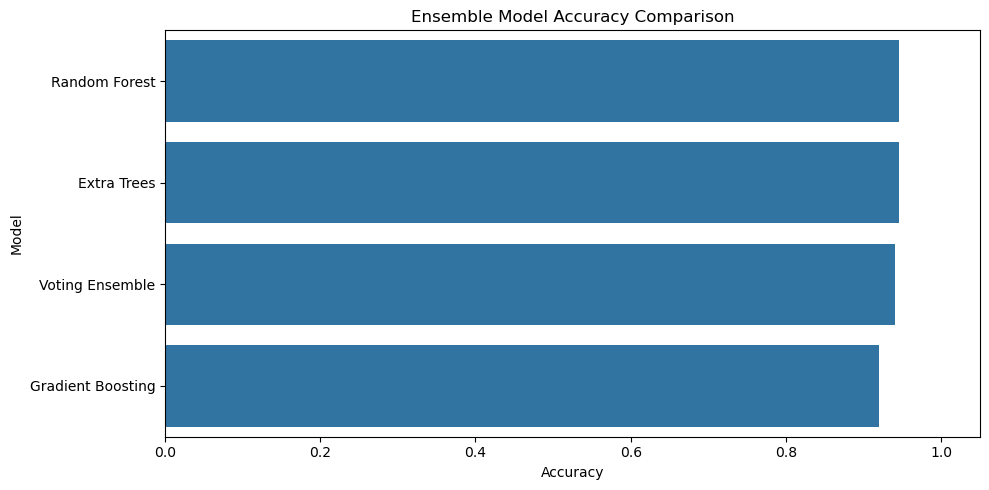

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='Accuracy', y='Model')
plt.xlim(0, 1.05)
plt.title('Ensemble Model Accuracy Comparison')
plt.tight_layout()
plt.show()

In [16]:
## 6. Classification Report for Voting Ensemble

In [17]:
best_model = trained_models['Voting Ensemble']
y_pred = best_model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))


Accuracy: 0.94

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        10
      banana       1.00      1.00      1.00        10
   blackgram       0.91      1.00      0.95        10
    chickpea       1.00      1.00      1.00        10
     coconut       1.00      1.00      1.00        10
      cotton       1.00      1.00      1.00        10
      grapes       1.00      1.00      1.00        10
 kidneybeans       1.00      1.00      1.00        10
      lentil       0.89      0.80      0.84        10
       maize       1.00      1.00      1.00        10
       mango       1.00      1.00      1.00        10
   mothbeans       1.00      0.80      0.89        10
    mungbean       0.83      1.00      0.91        10
   muskmelon       0.62      0.50      0.56        10
      orange       1.00      1.00      1.00        10
      papaya       1.00      1.00      1.00        10
  pigeonpeas       1.00      1.00      1.

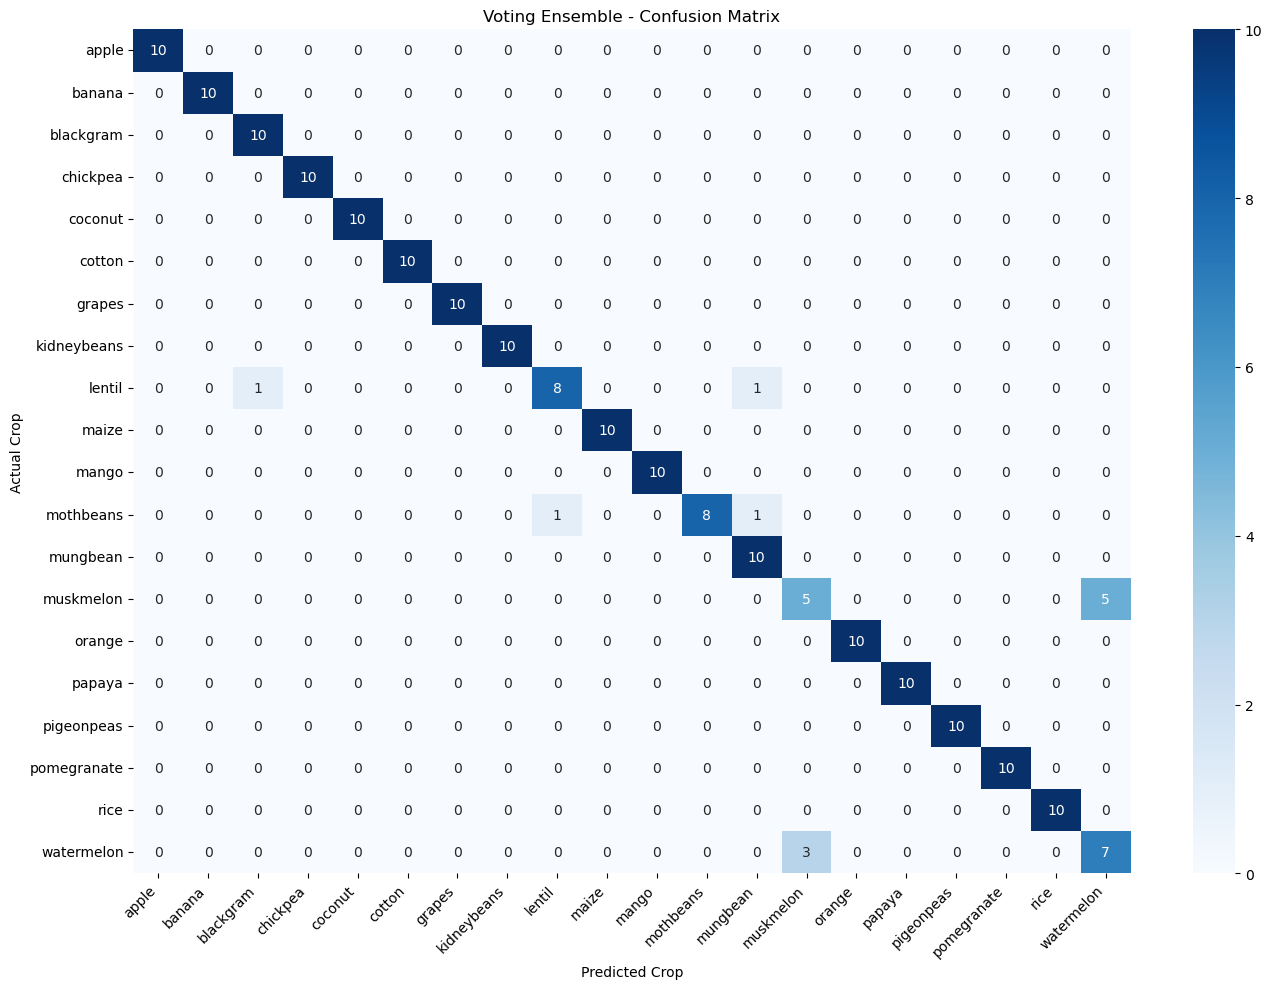

In [18]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(14,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Voting Ensemble - Confusion Matrix')
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Feature Importance

Random Forest is used here to inspect which input variables contribute most to crop recommendation.

,Importance
rainfall,0.214105
P,0.186724
N,0.162713
K,0.155697
humidity,0.116651
temperature,0.110050
ph,0.054059


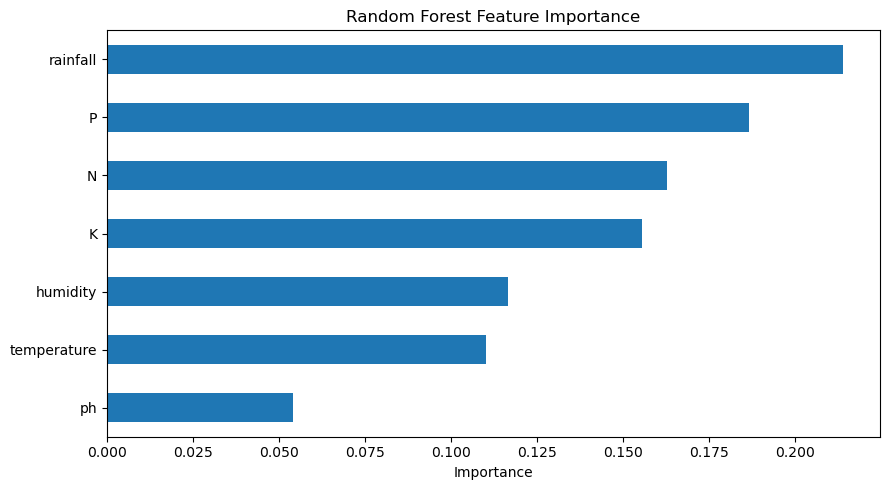

In [21]:
rf_model = trained_models['Random Forest']
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importance.to_frame('Importance'))

plt.figure(figsize=(9,5))
importance.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 8. Predict Crop for New User Input

Change the values below to the farmer/user's measured soil and weather conditions. The trained ensemble returns the recommended crop and top alternatives.

In [22]:
# Example user input: N, P, K, temperature, humidity, ph, rainfall
new_data = pd.DataFrame([{
    'N': 90,
    'P': 42,
    'K': 43,
    'temperature': 25.5,
    'humidity': 80,
    'ph': 6.3,
    'rainfall': 210
}])

prediction = best_model.predict(new_data)[0]
probabilities = best_model.predict_proba(new_data)[0]
classes = best_model.classes_

top_indices = np.argsort(probabilities)[::-1][:5]
top_predictions = pd.DataFrame({
    'Crop': classes[top_indices],
    'Probability': probabilities[top_indices]
})

print('Recommended Crop:', prediction)
display(top_predictions)

Recommended Crop: rice


,Crop,Probability
0,rice,0.973333
1,maize,0.015000
2,papaya,0.006667
3,coconut,0.001667
4,cotton,0.001667


## 9. Optional: Stacking Ensemble

For an additional ensemble approach, a stacking classifier can combine different base learners through a final Logistic Regression estimator.

In [ ]:
stacking_model = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=150, random_state=42)),
        ('et', ExtraTreesClassifier(n_estimators=150, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)
stack_pred = stacking_model.predict(X_test)
print('Stacking Ensemble Accuracy:', round(accuracy_score(y_test, stack_pred), 4))


## 10. Conclusion

The crop recommendation system uses multiple ensemble-learning techniques. The Voting Ensemble combines Random Forest, Extra Trees and Gradient Boosting predictions. The final section demonstrates how the trained model can recommend a crop from newly entered N, P, K, temperature, humidity, pH and rainfall values.

**Note:** The included 1,000-row dataset is a synthetic educational dataset generated around crop-specific agronomic ranges. For a real deployment or academic result validation, replace it with a verified agricultural dataset from a trusted source.